# SmartFood Rescue — YOLO Classification

Notebook ini menggabungkan proses pengecekan dataset, pembagian data, penyeimbangan kelas pada data train, training YOLO classification, evaluasi, dan inference.

Dataset yang digunakan memiliki dua kelas: **Fresh** dan **Rotten**.

> Catatan: karena dataset awal tidak memiliki bounding box, notebook ini menggunakan **YOLO Classification**, bukan object detection.

## 1. Instalasi library

Jalankan sel ini sekali pada environment `.venv` atau kernel Python yang digunakan.

In [1]:
# %pip install -U pillow ultralytics scikit-learn matplotlib seaborn pandas

## 2. Konfigurasi path project

Notebook ini diasumsikan berada di folder utama project `SistemCerdas_FoodWaste` atau dijalankan dari folder tersebut.

In [2]:
from pathlib import Path
import random
import shutil
from collections import Counter

ROOT = Path('/mnt/d/Semester 7/SistemCerdas_FoodWaste')

# Jika notebook dijalankan dari folder lain, ubah ROOT secara manual, contoh:
# ROOT = Path('/mnt/d/Semester 7/SistemCerdas_FoodWaste')

DATASET_RAW = ROOT / 'dataset'
OUTPUT_DIR = ROOT / 'Dataset_YOLO'

GOOD_DIR = DATASET_RAW / 'Good Quality'
BAD_DIR = DATASET_RAW / 'Bad Quality'

SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
random.seed(SEED)

print('ROOT       :', ROOT)
print('GOOD_DIR   :', GOOD_DIR)
print('BAD_DIR    :', BAD_DIR)
print('OUTPUT_DIR :', OUTPUT_DIR)

ROOT       : /mnt/d/Semester 7/SistemCerdas_FoodWaste
GOOD_DIR   : /mnt/d/Semester 7/SistemCerdas_FoodWaste/dataset/Good Quality
BAD_DIR    : /mnt/d/Semester 7/SistemCerdas_FoodWaste/dataset/Bad Quality
OUTPUT_DIR : /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO


## 3. Pengecekan dataset mentah

In [3]:
from PIL import Image

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def get_images(folder):
    return [
        p for p in folder.rglob('*')
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

def check_images(images):
    corrupt = []
    for path in images:
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            corrupt.append(path)
    return corrupt

assert GOOD_DIR.exists(), f'Folder tidak ditemukan: {GOOD_DIR}'
assert BAD_DIR.exists(), f'Folder tidak ditemukan: {BAD_DIR}'

good_images = get_images(GOOD_DIR)
bad_images = get_images(BAD_DIR)
all_images = good_images + bad_images

print(f'Fresh : {len(good_images):,} gambar')
print(f'Rotten: {len(bad_images):,} gambar')
print(f'Total : {len(all_images):,} gambar')

corrupt_images = check_images(all_images)
print(f'File corrupt: {len(corrupt_images)}')
if corrupt_images:
    for path in corrupt_images[:10]:
        print(' -', path)

Fresh : 24,386 gambar
Rotten: 15,530 gambar
Total : 39,916 gambar
File corrupt: 0


## 4. Membagi data dan melakukan oversampling pada train

In [4]:
def split_data(images):
    images = list(images)
    random.shuffle(images)
    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)
    return images[:train_end], images[train_end:val_end], images[val_end:]

def oversample(images, target_count):
    images = list(images)
    if not images:
        raise ValueError('Tidak ada gambar untuk di-oversample.')
    result = images.copy()
    while len(result) < target_count:
        result.append(random.choice(images))
    random.shuffle(result)
    return result

good_train, good_val, good_test = split_data(good_images)
bad_train, bad_val, bad_test = split_data(bad_images)

target_train = max(len(good_train), len(bad_train))
good_train_balanced = oversample(good_train, target_train)
bad_train_balanced = oversample(bad_train, target_train)

print('Pembagian sebelum oversampling:')
print('Fresh  train:', len(good_train))
print('Rotten train:', len(bad_train))
print('Fresh  val  :', len(good_val))
print('Rotten val  :', len(bad_val))
print('Fresh  test :', len(good_test))
print('Rotten test :', len(bad_test))

print('\nTrain setelah oversampling:')
print('Fresh  train:', len(good_train_balanced))
print('Rotten train:', len(bad_train_balanced))

Pembagian sebelum oversampling:
Fresh  train: 17070
Rotten train: 10871
Fresh  val  : 3657
Rotten val  : 2329
Fresh  test : 3659
Rotten test : 2330

Train setelah oversampling:
Fresh  train: 17070
Rotten train: 17070


## 5. Membuat struktur folder YOLO Classification

In [5]:
def copy_images(images, destination):
    destination.mkdir(parents=True, exist_ok=True)
    for index, image_path in enumerate(images):
        new_name = f'{index:06d}_{image_path.name}'
        shutil.copy2(image_path, destination / new_name)

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

copy_images(good_train_balanced, OUTPUT_DIR / 'train' / 'Fresh')
copy_images(bad_train_balanced, OUTPUT_DIR / 'train' / 'Rotten')
copy_images(good_val, OUTPUT_DIR / 'val' / 'Fresh')
copy_images(bad_val, OUTPUT_DIR / 'val' / 'Rotten')
copy_images(good_test, OUTPUT_DIR / 'test' / 'Fresh')
copy_images(bad_test, OUTPUT_DIR / 'test' / 'Rotten')

print('[OK] Dataset berhasil dibuat di:', OUTPUT_DIR)
for split in ['train', 'val', 'test']:
    for cls in ['Fresh', 'Rotten']:
        folder = OUTPUT_DIR / split / cls
        print(f'{split:5} | {cls:6} | {len(list(folder.iterdir())):,} gambar')

[OK] Dataset berhasil dibuat di: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO
train | Fresh  | 17,070 gambar
train | Rotten | 17,070 gambar
val   | Fresh  | 3,657 gambar
val   | Rotten | 2,329 gambar
test  | Fresh  | 3,659 gambar
test  | Rotten | 2,330 gambar


## 6. Training YOLO Classification

Untuk GPU terbatas, mulai dari `yolo11n-cls.pt`, `imgsz=224`, dan epoch sekitar 30–50. Jika model atau nama checkpoint berbeda pada versi Ultralytics yang terpasang, gunakan checkpoint classification yang tersedia pada versi tersebut.

In [6]:
from ultralytics import YOLO

MODEL_NAME = 'yolo11n-cls.pt'
RUNS_DIR = ROOT / 'runs'

model = YOLO(MODEL_NAME)

results = model.train(
    data=str(OUTPUT_DIR),
    epochs=20,
    imgsz=224,
    batch=16,
    patience=8,
    workers=0,
    project=str(RUNS_DIR),
    name='freshness_yolo_cls',
    pretrained=True,
    verbose=True
)

print('[OK] Training selesai.')

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/asus/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


/home/asus/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Ultralytics 8.4.153 🚀 Python-3.10.20 torch-2.14.0+cu130 CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=f

/home/asus/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/torch/cuda/__init__.py:228: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12070). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


train: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/train... found 34140 images in 2 classes ✅ 
val: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/val... found 5986 images in 2 classes ✅ 
test: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/test... found 5989 images in 2 classes ✅ 
Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [

## 7. Evaluasi pada validation dan test

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

best_model_path = RUNS_DIR / 'freshness_yolo_cls' / 'weights' / 'best.pt'
best_model = YOLO(str(best_model_path))

val_results = best_model.val(data=str(OUTPUT_DIR), split='val', imgsz=224)
print(val_results)

print('\nEvaluasi test:')
test_results = best_model.val(data=str(OUTPUT_DIR), split='test', imgsz=224)
print(test_results)

Ultralytics 8.4.153 🚀 Python-3.10.20 torch-2.14.0+cu130 CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)
YOLO11n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/train... found 34140 images in 2 classes ✅ 
val: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/val... found 5986 images in 2 classes ✅ 
test: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/test... found 5989 images in 2 classes ✅ 
WARNING ⚠️ val: Slow image access detected (ping: 2.1±0.2 ms, read: 34.9±66.1 MB/s, size: 335.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/val... 5986 images, 0 corrupt: 100% ━━━━━━━━━━━━ 5986/5986 165.2Mit/s 0.0s
val: /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/val/Fresh/001526_freshCarrot (475).jpg: corrupt JPEG restored and 

## 8. Prediksi satu gambar

In [8]:
def recommendation(label, confidence):
    if label.lower() == 'fresh':
        return 'Kondisi visual terindikasi segar. Tangani dan simpan sesuai kondisi penyimpanan yang tepat.'
    return 'Terindikasi busuk secara visual. Pisahkan dari bahan lain dan jangan menganggap hasil model sebagai jaminan keamanan pangan.'

# Ganti dengan path gambar yang ingin diuji
IMAGE_TO_TEST = OUTPUT_DIR / 'test' / 'Fresh'
sample_images = list(IMAGE_TO_TEST.glob('*'))

if sample_images:
    image_path = sample_images[0]
    prediction = best_model(str(image_path), verbose=False)[0]
    top1_index = int(prediction.probs.top1)
    confidence = float(prediction.probs.top1conf)
    label = prediction.names[top1_index]

    print('Gambar    :', image_path)
    print('Prediksi  :', label)
    print('Confidence:', f'{confidence:.2%}')
    print('Saran     :', recommendation(label, confidence))
else:
    print('Tidak ada gambar contoh pada folder test/Fresh.')

Gambar    : /mnt/d/Semester 7/SistemCerdas_FoodWaste/Dataset_YOLO/test/Fresh/000000_freshStrawberry (527).jpg
Prediksi  : Fresh
Confidence: 100.00%
Saran     : Kondisi visual terindikasi segar. Tangani dan simpan sesuai kondisi penyimpanan yang tepat.


# TEST

In [9]:
from ultralytics import YOLO
from pathlib import Path

# Lokasi model hasil training
best_model_path = (
    ROOT / "runs" / "freshness_yolo_cls" / "weights" / "best.pt"
)

# Load model terbaik
model = YOLO(str(best_model_path))

print("Model berhasil dimuat!")

Model berhasil dimuat!


## Prediksi Gambar


image 1/1 /mnt/d/Semester 7/SistemCerdas_FoodWaste/dataset/test/images_tomato.jpg: 224x224 Rotten 1.00, Fresh 0.00, 18.0ms
Speed: 5.8ms preprocess, 18.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
File: images_tomato.jpg
Prediksi: Rotten
Confidence: 100.00%
Rekomendasi: Bahan terindikasi busuk secara visual. Pisahkan dari bahan lain dan jangan dikonsumsi hanya berdasarkan hasil model.


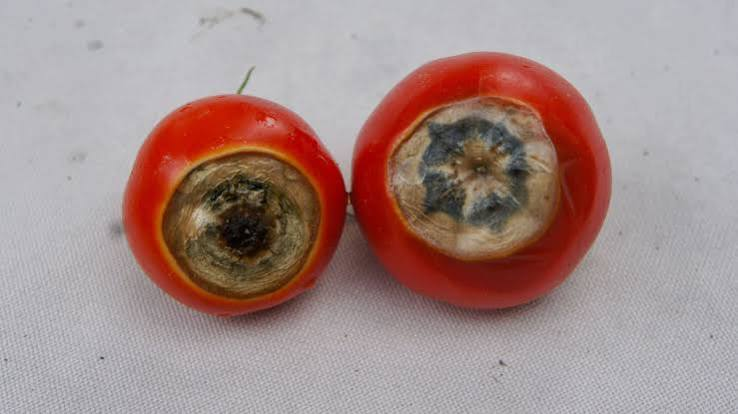

In [15]:
from pathlib import Path
from PIL import Image

# Path gambar uji
image_path = Path(
    "/mnt/d/Semester 7/SistemCerdas_FoodWaste/dataset/test"
)

# Ambil satu gambar dari folder
image_files = list(image_path.glob("*.*"))

if not image_files:
    raise FileNotFoundError(
        f"Tidak ada gambar ditemukan di folder: {image_path}"
    )

image_file = image_files[0]

# Jalankan prediksi
results = model(str(image_file))
result = results[0]

# Ambil label dan confidence
top1_index = int(result.probs.top1)
label = result.names[top1_index].lower()
confidence = float(result.probs.top1conf)

# Fungsi rekomendasi
def recommendation(label, confidence):
    label = label.lower()

    if label == "fresh":
        return (
            "Bahan terindikasi segar secara visual. "
            "Simpan dan tangani sesuai kondisi penyimpanan "
            "yang tepat. Hasil model bukan jaminan keamanan pangan."
        )

    elif label == "rotten":
        return (
            "Bahan terindikasi busuk secara visual. "
            "Pisahkan dari bahan lain dan jangan dikonsumsi "
            "hanya berdasarkan hasil model."
        )

    return (
        "Hasil klasifikasi tidak dikenali. "
        "Periksa kembali model dan kelas dataset."
    )

# Tampilkan hasil
print("File:", image_file.name)
print("Prediksi:", label.capitalize())
print("Confidence:", f"{confidence:.2%}")
print("Rekomendasi:", recommendation(label, confidence))

# Tampilkan gambar
display(Image.open(image_file))